<a href="https://colab.research.google.com/github/prakharsrivcodes/Naive-Bayes-mini-project/blob/main/SpamClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv

--2026-08-31 14:32:21--  https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 477907 (467K) [text/plain]
Saving to: ‘sms.tsv’

sms.tsv             100%[===================>] 466.71K  --.-KB/s    in 0.08s   

2026-08-31 14:32:21 (5.88 MB/s) - ‘sms.tsv’ saved [477907/477907]



In [ ]:
import pandas as pd

df = pd.read_csv('sms.tsv', sep='\t', header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print(df.shape)
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [ ]:
import re
import string
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from scipy.sparse import hstack


In [ ]:

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    # \d+ refers to one or more digits substituted by ' '
    text = text.translate(str.maketrans('', '', string.punctuation))
    # removes to punctuations and making them lowercase
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df['clean_message'] = df['message'].apply(clean_text)
df['msg_len'] = df['message'].apply(len)
df['punct_count'] = df['message'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
df['upper_ratio'] = df['message'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

In [ ]:
X_text = df['clean_message']
X_extra = df[['msg_len', 'punct_count', 'upper_ratio']].values
y = df['label_num']

X_train_text, X_test_text, X_train_extra, X_test_extra, y_train, y_test = train_test_split(
    X_text, X_extra, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


In [ ]:
X_train_final = hstack([X_train_tfidf, X_train_extra])
X_test_final = hstack([X_test_tfidf, X_test_extra])

Best alpha: {'alpha': 0.01}
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.97      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

ROC-AUC: 0.9881473453110454


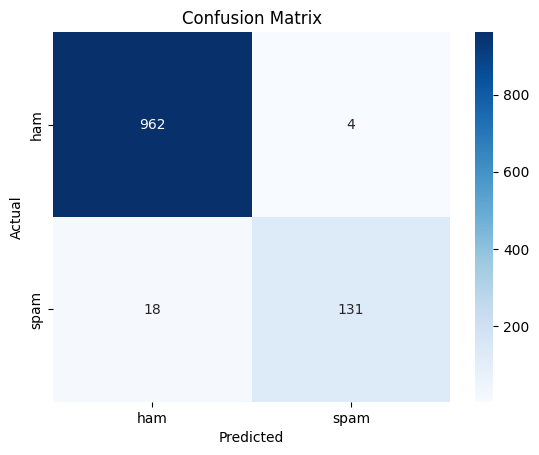

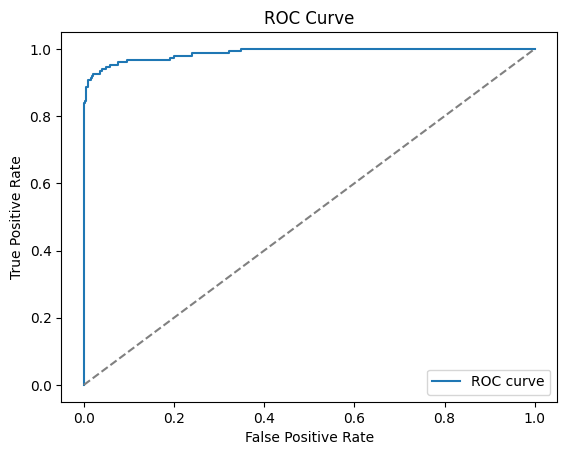

In [ ]:
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='f1')
grid.fit(X_train_final, y_train)

print("Best alpha:", grid.best_params_)
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['ham','spam'], yticklabels=['ham','spam'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()